# Phase 2 — Step 2: Labeling (Buy / Sell / Hold)

## Apa yang kita lakukan di notebook ini?

Di Phase 1, model LSTM kita dilatih untuk menjawab pertanyaan:
> *"Berapa harga AAPL besok?"*

Di Phase 2, kita mau menjawab pertanyaan yang berbeda:
> *"Hari ini, haruskah kita beli, jual, atau hold?"*

Masalahnya — data historis tidak punya kolom 'BUY' atau 'SELL'.
Kita harus **membuatnya sendiri** dari data harga yang sudah ada.

Caranya: kita lihat ke depan (future return) untuk setiap hari,
lalu putuskan label berdasarkan hasilnya.

---

### Konsep: Future Return

```
future_return = (harga N hari ke depan - harga hari ini) / harga hari ini
```

Contoh nyata:
- Hari ini harga AAPL = $200
- 5 hari lagi harga AAPL = $206
- future_return = (206 - 200) / 200 = **+3%** → kita label hari ini sebagai **BUY**

Karena kita pakai data historis, kita boleh 'curang' lihat ke depan.
Nanti saat model sudah terlatih, dia akan bisa *memprediksi* sinyal ini
tanpa perlu lihat ke depan.

---

### Threshold yang kita pakai

| future_return | Label | Kode angka |
|---|---|---|
| > +2% | BUY  | 2 |
| < -2% | SELL | 0 |
| di antaranya | HOLD | 1 |

Kenapa 2%? Karena itu angka yang cukup signifikan untuk menutup
biaya transaksi (komisi broker, spread), tapi tidak terlalu besar
sehingga sinyal jadi terlalu jarang muncul.
Kita juga akan eksperimen dengan nilai lain di bagian akhir notebook.

## Bagian 1 — Setup & Download Data

Sama persis dengan Phase 1a — kita download ulang data AAPL
dan hitung semua indikator teknikal yang sudah kita buat.

In [27]:
import pandas as pd
import numpy as np
import yfinance as yf
import ta
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import os
warnings.filterwarnings('ignore')

# Download data AAPL
START = '2018-01-01'
END   = '2024-12-31'

aapl = yf.download('AAPL', start=START, end=END)
aapl.columns = aapl.columns.get_level_values(0)  # rapikan MultiIndex kalau ada
aapl = aapl[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

print(f'Data downloaded: {len(aapl)} hari trading')
print(f'Periode: {aapl.index[0].date()} s/d {aapl.index[-1].date()}')
aapl.tail(3)

[*********************100%***********************]  1 of 1 completed

Data downloaded: 1760 hari trading
Periode: 2018-01-02 s/d 2024-12-30


Price,Open,High,Low,Close,Volume
Date,,,,,
2024-12-26,256.550893,258.448771,255.994450,257.375610,27237100
2024-12-27,256.193162,257.057664,251.453455,253.967392,42355300
2024-12-30,250.628701,251.890642,249.158101,250.598892,35557500


In [28]:
# Hitung semua indikator teknikal — sama persis dengan Phase 1a

# RSI
aapl['RSI'] = ta.momentum.RSIIndicator(aapl['Close'], window=14).rsi()

# MACD
macd_obj = ta.trend.MACD(aapl['Close'], window_fast=12, window_slow=26, window_sign=9)
aapl['MACD']        = macd_obj.macd()
aapl['MACD_Signal'] = macd_obj.macd_signal()
aapl['MACD_Hist']   = macd_obj.macd_diff()

# Bollinger Bands
bb_obj = ta.volatility.BollingerBands(aapl['Close'], window=20, window_dev=2)
aapl['BB_Upper']  = bb_obj.bollinger_hband()
aapl['BB_Middle'] = bb_obj.bollinger_mavg()
aapl['BB_Lower']  = bb_obj.bollinger_lband()
aapl['BB_Width']  = (aapl['BB_Upper'] - aapl['BB_Lower']) / aapl['BB_Middle']

# SMA
aapl['SMA_20'] = ta.trend.SMAIndicator(aapl['Close'], window=20).sma_indicator()
aapl['SMA_50'] = ta.trend.SMAIndicator(aapl['Close'], window=50).sma_indicator()

# Volume & Return
aapl['Volume_Ratio'] = aapl['Volume'] / aapl['Volume'].rolling(20).mean()
aapl['Daily_Return'] = aapl['Close'].pct_change()

print('Semua indikator teknikal selesai dihitung.')
print(f'Kolom sekarang: {list(aapl.columns)}')

Semua indikator teknikal selesai dihitung.
Kolom sekarang: ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_Width', 'SMA_20', 'SMA_50', 'Volume_Ratio', 'Daily_Return']


## Bagian 2 — Membuat Label Buy / Sell / Hold

Ini inti dari notebook ini.

Kita akan tambah dua kolom baru:
- `Future_Return` — persentase perubahan harga 5 hari ke depan
- `Signal` — label keputusan: 0=SELL, 1=HOLD, 2=BUY

### Kenapa 5 hari?

5 hari trading = 1 minggu kalender.
Ini horizon yang cukup untuk:
- Menghindari noise harian (terlalu pendek → sinyal palsu banyak)
- Tidak terlalu jauh ke depan (10+ hari → terlalu spekulatif)

Kita bisa eksperimen dengan nilai lain nanti.

In [29]:
# Parameter labeling — bisa kamu ubah dan eksperimen
HORIZON   = 5     # prediksi return N hari ke depan
THRESHOLD = 0.02  # 2% threshold untuk BUY/SELL

# --- Hitung Future Return ---
# .shift(-HORIZON) artinya: geser data ke ATAS sebanyak HORIZON baris
# Efeknya: nilai di baris hari-ini menjadi nilai harga HORIZON-hari-ke-depan
#
# Contoh dengan HORIZON=5:
#   Baris tanggal 1 Jan → future_close = harga 6 Jan
#   Baris tanggal 2 Jan → future_close = harga 7 Jan
#   ... dan seterusnya
#
# N baris terakhir akan jadi NaN karena tidak ada data masa depannya
future_close = aapl['Close'].shift(-HORIZON)
aapl['Future_Return'] = (future_close - aapl['Close']) / aapl['Close']

# --- Assign Label ---
# Kita pakai np.select untuk kondisi bertingkat:
# kondisi pertama yang True yang akan dipakai
conditions = [
    aapl['Future_Return'] > THRESHOLD,    # naik > 2%  → BUY
    aapl['Future_Return'] < -THRESHOLD,   # turun > 2% → SELL
]
choices = [2, 0]  # BUY=2, SELL=0

# default=1 artinya: kalau tidak ada kondisi yang terpenuhi → HOLD
aapl['Signal'] = np.select(conditions, choices, default=1)

# --- Hapus baris NaN ---
# N baris terakhir tidak punya Future_Return → kita hapus
aapl = aapl.dropna()

print(f'Labeling selesai!')
print(f'Total data: {len(aapl)} hari')
print(f'5 baris terakhir dihapus (tidak ada data masa depan)')

Labeling selesai!
Total data: 1706 hari
5 baris terakhir dihapus (tidak ada data masa depan)


## Bagian 3 — Cek Distribusi Label

Ini langkah penting yang sering dilupakan!

Kita perlu tahu: apakah label BUY, SELL, HOLD jumlahnya seimbang?

Kalau tidak seimbang (misal 80% HOLD, 10% BUY, 10% SELL),
model akan 'malas' dan cenderung selalu prediksi HOLD karena
itu paling aman secara statistik — masalah ini namanya **class imbalance**.

In [30]:
# Hitung distribusi label
label_map   = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
label_names = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}

counts = aapl['Signal'].value_counts().sort_index()
total  = len(aapl)

print('=== Distribusi Label ===')
print(f'Parameter: HORIZON={HORIZON} hari, THRESHOLD={THRESHOLD*100:.0f}%')
print()
for code, count in counts.items():
    name = label_names[code]
    pct  = count / total * 100
    bar  = '█' * int(pct / 2)
    print(f'  {name:4s} ({code}): {count:4d} hari  {pct:5.1f}%  {bar}')

print()
# Evaluasi keseimbangan
buy_pct  = counts.get(2, 0) / total * 100
sell_pct = counts.get(0, 0) / total * 100
hold_pct = counts.get(1, 0) / total * 100

if hold_pct > 60:
    print('⚠️  HOLD mendominasi — pertimbangkan turunkan threshold atau perbesar horizon')
elif abs(buy_pct - sell_pct) > 15:
    print('⚠️  BUY dan SELL tidak seimbang — perlu class weighting saat training')
else:
    print('✅ Distribusi label cukup seimbang — siap lanjut ke modeling')

=== Distribusi Label ===
Parameter: HORIZON=5 hari, THRESHOLD=2%

  SELL (0):  384 hari   22.5%  ███████████
  HOLD (1):  712 hari   41.7%  ████████████████████
  BUY  (2):  610 hari   35.8%  █████████████████

✅ Distribusi label cukup seimbang — siap lanjut ke modeling


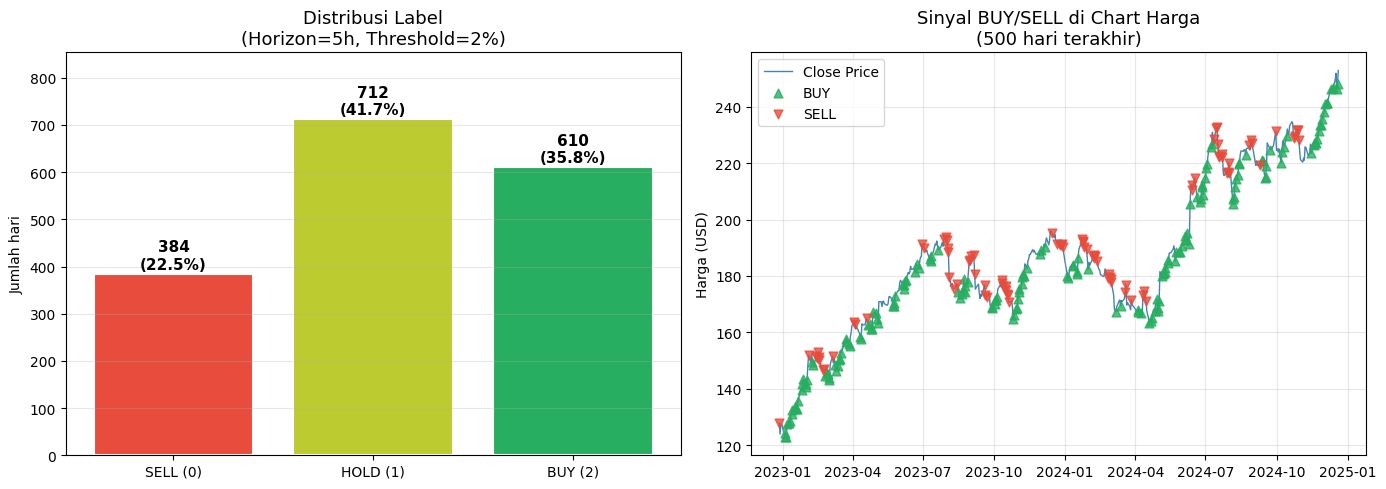

Plot disimpan.


In [31]:
# Visualisasi distribusi label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Bar chart distribusi ---
colors = ['#e74c3c', "#bccb2f", '#27ae60']  # merah, kuning, hijau
labels = ['SELL (0)', 'HOLD (1)', 'BUY (2)']
values = [counts.get(0, 0), counts.get(1, 0), counts.get(2, 0)]

bars = axes[0].bar(labels, values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title(f'Distribusi Label\n(Horizon={HORIZON}h, Threshold={THRESHOLD*100:.0f}%)', fontsize=13)
axes[0].set_ylabel('Jumlah hari')

for bar, val in zip(bars, values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{val}\n({val/total*100:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_ylim(0, max(values) * 1.2)
axes[0].grid(axis='y', alpha=0.3)

# --- Plot 2: Harga + sinyal buy/sell ---
# Kita plot 2 tahun terakhir agar tidak terlalu padat
plot_data = aapl.iloc[-500:]

axes[1].plot(plot_data.index, plot_data['Close'],
             color='steelblue', linewidth=1, label='Close Price', zorder=1)

buy_days  = plot_data[plot_data['Signal'] == 2]
sell_days = plot_data[plot_data['Signal'] == 0]

axes[1].scatter(buy_days.index,  buy_days['Close'],
                color='#27ae60', marker='^', s=40, label='BUY',  zorder=3, alpha=0.8)
axes[1].scatter(sell_days.index, sell_days['Close'],
                color='#e74c3c', marker='v', s=40, label='SELL', zorder=3, alpha=0.8)

axes[1].set_title('Sinyal BUY/SELL di Chart Harga\n(500 hari terakhir)', fontsize=13)
axes[1].set_ylabel('Harga (USD)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
os.makedirs('../../reports', exist_ok=True)
plt.savefig('../../reports/phase2_label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot disimpan.')

## Bagian 4 — Eksperimen Threshold

Tidak ada nilai threshold yang 'benar' — tergantung strategi trading kamu.

| Threshold | Efek |
|---|---|
| Kecil (1%) | Sinyal lebih sering muncul, tapi lebih banyak noise |
| Sedang (2%) | Balance antara frekuensi dan kualitas sinyal |
| Besar (3-5%) | Sinyal jarang tapi lebih 'yakin' — cocok untuk swing trading |

Kita cek beberapa kombinasi sekaligus:

In [32]:
# Eksperimen: lihat efek berbagai kombinasi threshold + horizon
print('=== Eksperimen Threshold & Horizon ===')
print(f'{"Threshold":>10} {"Horizon":>8} {"SELL%":>7} {"HOLD%":>7} {"BUY%":>7} {"Verdict":>20}')
print('-' * 65)

for h in [3, 5, 10]:
    for t in [0.01, 0.02, 0.03]:
        fc  = aapl['Close'].shift(-h)
        fr  = (fc - aapl['Close']) / aapl['Close']
        sig = np.select([fr > t, fr < -t], [2, 0], default=1)
        sig = sig[~np.isnan(fr)]  # hapus NaN

        n     = len(sig)
        s_pct = (sig == 0).sum() / n * 100
        h_pct = (sig == 1).sum() / n * 100
        b_pct = (sig == 2).sum() / n * 100

        if h_pct > 70:
            verdict = '⚠️ HOLD dominan'
        elif abs(b_pct - s_pct) > 15:
            verdict = '⚠️ Tidak seimbang'
        else:
            verdict = '✅ Oke'

        print(f'{t*100:>9.0f}% {h:>7}h {s_pct:>6.1f}% {h_pct:>6.1f}% {b_pct:>6.1f}%  {verdict}')
    print()

=== Eksperimen Threshold & Horizon ===
 Threshold  Horizon   SELL%   HOLD%    BUY%              Verdict
-----------------------------------------------------------------
        1%       3h   28.8%   29.2%   42.0%  ✅ Oke
        2%       3h   18.4%   54.4%   27.2%  ✅ Oke
        3%       3h   11.5%   73.2%   15.3%  ⚠️ HOLD dominan

        1%       5h   31.2%   20.9%   47.9%  ⚠️ Tidak seimbang
        2%       5h   22.6%   41.7%   35.7%  ✅ Oke
        3%       5h   16.5%   59.1%   24.5%  ✅ Oke

        1%      10h   32.9%   12.5%   54.6%  ⚠️ Tidak seimbang
        2%      10h   27.1%   25.9%   47.0%  ⚠️ Tidak seimbang
        3%      10h   21.6%   39.3%   39.2%  ⚠️ Tidak seimbang



## Bagian 5 — Simpan Dataset Berlabel

Dataset ini yang akan dipakai di Step 3 (modeling klasifikasi).

Kita simpan dalam dua format:
- **CSV** — mudah dilihat dan dicek manual
- **Pickle** — mempertahankan tipe data dengan sempurna untuk Python

In [33]:
import os
os.makedirs('../../data/processed', exist_ok=True)

# Kolom yang kita simpan: semua fitur + label
FEATURES = [
    'Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal',
    'BB_Width', 'SMA_20', 'SMA_50', 'Volume_Ratio', 'Daily_Return'
]
LABEL = 'Signal'

# Dataset final
df_final = aapl[FEATURES + ['Future_Return', LABEL]].copy()

# Simpan
df_final.to_csv('../../data/processed\\aapl_labeled.csv', index=False)
df_final.to_pickle('../../data/processed\\aapl_labeled.pkl')

print('=== Dataset Berlabel Tersimpan ===')
print(f'File: ../../data/processed\\aapl_labeled.csv')
print(f'File: ../../data/processed\\aapl_labeled.pkl')
print(f'Shape: {df_final.shape}  ({df_final.shape[0]} hari x {df_final.shape[1]} kolom)')
print()
print('5 baris terakhir:')
print(df_final.tail())
print()
print('Kolom Signal:')
print('  0 = SELL  |  1 = HOLD  |  2 = BUY')
print()
print('✅ Siap lanjut ke Step 3 — Model Klasifikasi!')

=== Dataset Berlabel Tersimpan ===
File: ../../data/processed\aapl_labeled.csv
File: ../../data/processed\aapl_labeled.pkl
Shape: (1706, 12)  (1706 hari x 12 kolom)

5 baris terakhir:
Price            Close     Volume        RSI      MACD  MACD_Signal  BB_Width  \
Date                                                                            
2024-12-16  249.446274   51694800  78.747838  5.393175     4.408382  0.127548   
2024-12-17  251.870804   51356400  80.923045  5.710392     4.668784  0.129500   
2024-12-18  246.475266   56774100  64.983009  5.463436     4.827714  0.123026   
2024-12-19  248.204208   60882300  67.211780  5.345611     4.931294  0.116476   
2024-12-20  252.874374  147495300  72.334111  5.564929     5.058021  0.110913   

Price           SMA_20      SMA_50  Volume_Ratio  Daily_Return  Future_Return  \
Date                                                                            
2024-12-16  237.639208  231.227885      1.220520      0.011728       0.016850   
2024-

---

## Ringkasan: Apa yang sudah kita lakukan?

| Langkah | Hasil |
|---|---|
| Download + feature engineering | Sama dengan Phase 1a |
| Hitung Future Return | Persentase perubahan harga 5 hari ke depan |
| Assign label BUY/SELL/HOLD | Berdasarkan threshold 2% |
| Cek distribusi | Pastikan tidak ada class yang dominan berlebihan |
| Eksperimen threshold | Pilih kombinasi horizon + threshold yang seimbang |
| Simpan dataset | Siap dipakai di Step 3 |

## Apa yang belum kita lakukan?

- Belum ada model yang belajar dari label ini → **Step 3**
- Belum dicek apakah sinyal ini profitable di dunia nyata → **Step 4 (Backtesting)**
- Label ini masih menggunakan threshold yang kita tentukan manual —
  ada metode yang lebih canggih namanya **Triple Barrier Method**
  yang bisa jadi upgrade di masa depan

---

**notes:**
Parameter yang paling mempengaruhi kualitas label adalah
kombinasi `HORIZON` dan `THRESHOLD`. Tidak ada nilai yang
universally benar — tergantung style trading yang kamu targetkan.
Lihat tabel eksperimen di Bagian 4 dan pilih kombinasi
yang distribusinya paling seimbang untuk saham yang kamu analisis.